# 비지도 학습

**감사의 글**

오렐리앙 제롱<font size='2'>Aurélien Géron</font>의 [Hands-On Machine Learning with Scikit-Learn and PyTorch (O'Reilly, 2025)](https://github.com/ageron/handson-mlp)에 사용된 코드를 참고한 강의노트이다. 보다 심화된 이해를 위해 책 원본을 읽을 것을 강력하게 권장한다. 자료를 공개한 오렐리앙 제롱과 일부 그림 자료를 제공해 준 한빛아카데미에게 진심어린 감사를 전한다.

**권장 사항**

[(강의노트) 비지도 학습](https://codingalzi.github.io/code-workout-ml/unsupervised-learning/)을 병행하여 읽을 것을 권장한다.

## 환경설정

Windows 운영체제에서 MKL을 사용하는 KMeans의 메모리 누수를 방지하기 위해 OpenMP 스레드 수를 1로 제한한다.

In [92]:
import os
import platform

if platform.system() == "Windows":
    os.environ["OMP_NUM_THREADS"] = "1"

This project requires Python 3.10 or above:

In [2]:
import sys

assert sys.version_info >= (3, 10)

It also requires Scikit-Learn ≥ 1.6.1:

In [3]:
from packaging.version import Version
import sklearn

assert Version(sklearn.__version__) >= Version("1.6.1")

As we did in previous chapters, let's define the default font sizes to make the figures prettier:

In [4]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

## 분류 대 군집화

**예제: 붓꽃 데이터셋 군집화**

- 붓꽃 데이터셋 불러오기

In [5]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

data = load_iris()
X = data.data
y = data.target
data.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

아래 코드는 분류와 군집화의 차이를 보여주는 그림을 그린다.

- 왼편: 각 샘플이 속하는 품종에 따른 분류
- 오른편: 지정된 기준에 따라 비슷한 샘플들끼리 그룹짓기

주의사항: 머신러닝 모델을 학습시킨 결과가 아니라 단순히 분류와 군집화의 차이점을 보여주는 산점도를 그린 것에 불과하다.

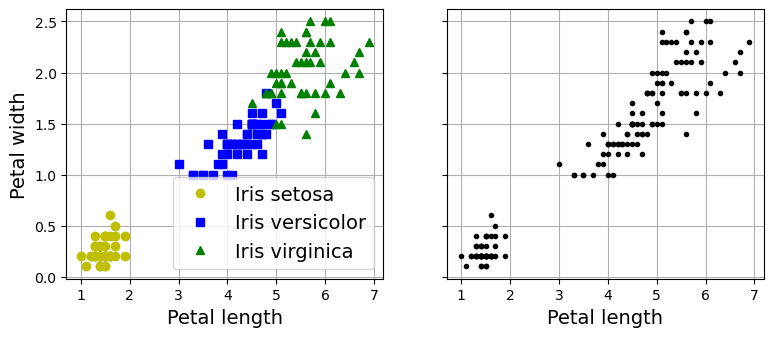

In [6]:
plt.figure(figsize=(9, 3.5))

plt.subplot(121)
plt.plot(X[y==0, 2], X[y==0, 3], "yo", label="Iris setosa")
plt.plot(X[y==1, 2], X[y==1, 3], "bs", label="Iris versicolor")
plt.plot(X[y==2, 2], X[y==2, 3], "g^", label="Iris virginica")
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.grid()
plt.legend()

plt.subplot(122)
plt.scatter(X[:, 2], X[:, 3], c="k", marker=".")
plt.xlabel("Petal length")
plt.tick_params(labelleft=False)
plt.gca().set_axisbelow(True)
plt.grid()

plt.show()

**예제: 가우스 혼합 모델 활용**

꽃잎 길이와 너비를 이용하면 두 개의 군집으로만 구분이 가능해 보인다. 하지만 꽃받침의 길이와 너비까지 포함한 네 개의 특성을 모두 사용하여 가우스 혼합 모델을 훈련시키면 세 개의 군집으로 나누는 게 가능하다.

- 3개의 군집 지정: 가우스 혼합 모델 이용

In [7]:
import numpy as np
from scipy import stats
from sklearn.mixture import GaussianMixture

y_pred = GaussianMixture(n_components=3, random_state=42).fit(X).predict(X)

c:\Users\gslee\miniforge3\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


`y_pred`를 확인하면 세토사는 1번 군집,
버시컬러와 버지니카 거의 대부분 2번과 0번 군집으로 구분된다.
일부 버시컬러와 버지니카 일부 샘플은 혼동되기도 한다.

In [8]:
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 0, 2, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

모든 세토사 샘플은 1번 군집에 할당되고, 버시컬러 샘플 대부분은 2번 군집에, 버지니카 샘플 대부분은 0번 군집에 할당된다. 다만 일부 버시컬러와 버지니카 샘플은 잘못된 군집에 할당된다.

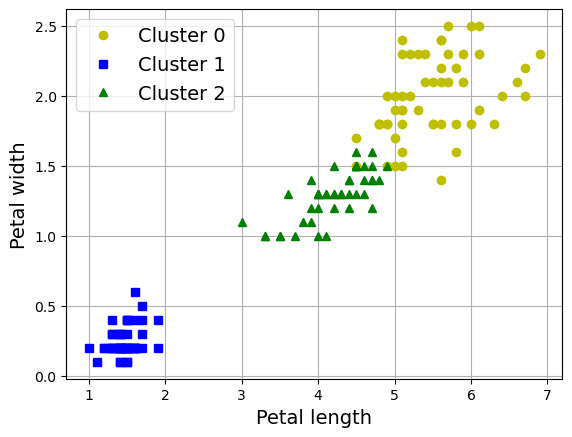

In [9]:

# y_pred = np.array([mapping[cluster_id] for cluster_id in y_pred])

plt.plot(X[y_pred==0, 2], X[y_pred==0, 3], "yo", label="Cluster 0")
plt.plot(X[y_pred==1, 2], X[y_pred==1, 3], "bs", label="Cluster 1")
plt.plot(X[y_pred==2, 2], X[y_pred==2, 3], "g^", label="Cluster 2")
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.legend(loc="upper left")
plt.grid()
plt.show()

군집화 정확도를 계산하려면 먼저 각 군집 번호를 해당 군집에서 가장 많은 비율을 차지하는 품종의 번호로 변환해야 한다. 변환 후 측정한 정확도는 96.7%이다.

In [10]:
mapping = {}
for class_id in np.unique(y):
    mode, _ = stats.mode(y_pred[y==class_id])
    mapping[mode] = class_id

y_pred = np.array([mapping[cluster_id] for cluster_id in y_pred])

In [11]:
(y_pred==y).sum() / len(y_pred)

np.float64(0.9666666666666667)

## K-평균

### 사이킷런의 `KMeans` 모델

**데이터셋 준비**

먼저 2,000개의 데이터 샘플을 생성한다.
`make_blobls()` 함수는 지정된 센터와 표준편차를 이용하여
지정된 수 만큼 원형 데이터셋을 생성한다.

이때 표준편차는 군집별 데이터의 분포를 가리키기에 결국 생성되는
군집을 가리키는 원의 반지름을 결정하게 된다.
또한 각 군집에 포함된 데이터샘플의 수는 거의 동일하게 구분된다.
따라서 표준편차가 크면 그만큼 데이터가 넓게 분포된다.
아래 코드는 총 2,000개의 데이터 샘플을 이용하여 5 개의 군집을 생성하기에
군집별로 약 400개의 샘플이 포함된다.

- `X`: 두 개의 특성으로 구성된 입력 데이터셋
- `y`: 0, 1, 2, 3, 4로 구성된 샘플별 군집 번호 (지도학습 용도에만 사용됨)

주의사항: `y` 는 각 데이터 샘플의 군집 번호(라벨)를 가리키지만 비지도 학습에서는 일반적으로 활용되지 않는다.

In [12]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# extra code – the exact arguments of make_blobs() are not important
blob_centers = np.array([[ 0.2,  2.3], [-1.5 ,  2.3], [-2.8,  1.8],
                         [-2.8,  2.8], [-2.8,  1.3]])
blob_std = np.array([0.4, 0.3, 0.1, 0.1, 0.1])
X, y = make_blobs(n_samples=2000, centers=blob_centers, cluster_std=blob_std,
                  random_state=7)

훈련셋 `X`의 산점도를 그리면 다음과 같다.

- `plot_clusters()` 함수: 두 특성을 각각 x, y 좌표로 이용하여 산점도를 그린다.

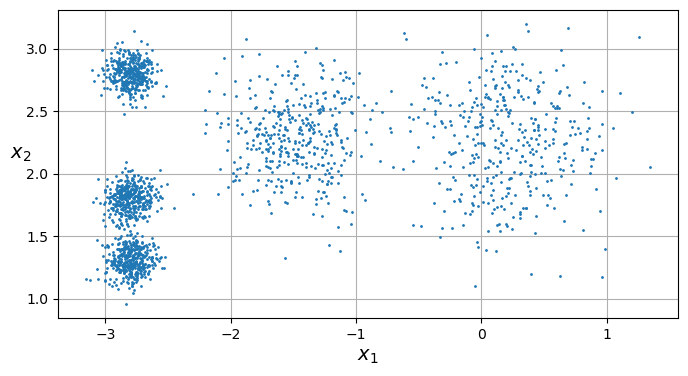

In [13]:
# extra code – this cell generates Figure 8–2

def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$", rotation=0)

plt.figure(figsize=(8, 4))
plot_clusters(X)
plt.gca().set_axisbelow(True)
plt.grid()

plt.show()

**k-평균 모델 훈련**

아래 `kmeans`는 5개의 군집으로 군집화를 학습하는 k-평균 모델을 지정한 후에 훈련시킨다.

In [14]:
k = 5
kmeans = KMeans(n_clusters=k, random_state=43)
kmeans.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",43
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


**예측값**

훈련셋들을 대상으로 군집 정보를 계산한다.

In [15]:
y_pred = kmeans.predict(X)

각 훈련 샘플이 속하는 군집은 0, 1, 2, 3, 4 의 인덱스로 지정된다.
생성된 인덱스가 타깃 라벨과는 무관함에 주의하라.

In [16]:
y_pred

array([4, 0, 1, ..., 2, 1, 0], shape=(2000,), dtype=int32)

**센트로이드 정보**

- `cluster_centers_` 속성: 5개 군집의 센트로이드의 좌표

In [17]:
kmeans.cluster_centers_

array([[-2.80389616,  1.80117999],
       [ 0.20876306,  2.25551336],
       [-2.79290307,  2.79641063],
       [-1.46679593,  2.28585348],
       [-2.80037642,  1.30082566]])

- `labels_` 속성: 군집 정보 저장

In [18]:
kmeans.labels_

array([4, 0, 1, ..., 2, 1, 0], shape=(2000,), dtype=int32)

- `predict()` 메서드: 새로운 데이터에 대한 군집 예측

In [19]:
import numpy as np

X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])
kmeans.predict(X_new)

array([1, 1, 2, 2], dtype=int32)

**결정 경계**

군집을 나누는 결정경계를 그리면 보로노이 다이어그램이 생성된다.

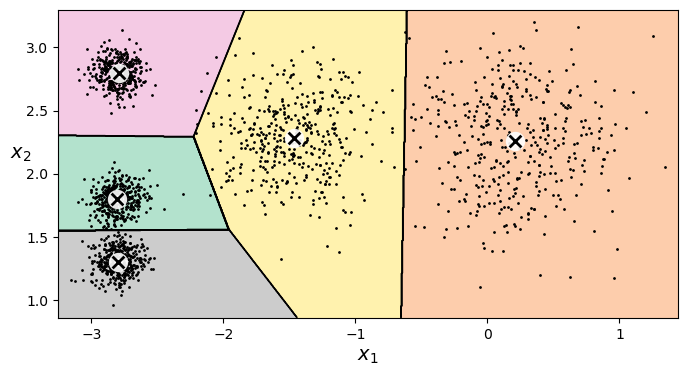

In [20]:
# extra code – this cell generates Figure 8–3

def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=35, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=12,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    if show_xlabels:
        plt.xlabel("$x_1$")
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", rotation=0)
    else:
        plt.tick_params(labelleft=False)

plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X)

plt.show()

### 센트로이드와의 거리

`KMeans` 모델의 `transform()` 메서드는 각 샘플과 모든 센트로이드 사이의 유클리드 거리를 계산하여 반환한다.
반환되는 배열의 열 하나는 센트로이드 하나에 대응하며, 값이 작을수록 해당 센트로이드에 가까움을 의미한다.
예를 들어, 다음 어레이는 앞서 주어진 새로운 4개 샘플과 각 센트로이드들과의 거리를 보여준다.

In [21]:
kmeans.transform(X_new).round(2)

array([[2.81, 0.33, 2.9 , 1.49, 2.89],
       [5.81, 2.8 , 5.85, 4.48, 5.84],
       [1.21, 3.29, 0.29, 1.69, 1.71],
       [0.73, 3.22, 0.36, 1.55, 1.22]])

### k-평균 알고리즘

K-평균 알고리즘은 가장 빠른 군집 알고리즘 중 하나이며, 동시에 가장 단순한 알고리즘 중 하나이다.

* 먼저 $k$개의 센트로이드를 무작위로 초기화한다. 예를 들어 데이터셋에서 서로 다른 $k$개의 샘플을 무작위로 선택하고, 선택된 샘플의 위치에 센트로이드를 배치한다.
* 수렴할 때까지, 즉 센트로이드가 더 이상 움직이지 않을 때까지 다음 과정을 반복한다.
    * 각 샘플을 가장 가까운 센트로이드에 할당한다.
    * 각 센트로이드를 자신에게 할당된 샘플들의 평균 위치로 갱신한다.

<div align="center"><img src="https://raw.githubusercontent.com/codingalzi/code-workout-ml/master/images/ch09/homl09-05.png" width="700"/></div>

**무작위 초기화 문제**

임의로 선택된 초기 센트로이드에 따라 매우 다른 모양과 성질의 군집이 생성될 수 있다.
아래 오른쪽 그림은 센트로이드 초기화가 다르면 최종 결과가 많이 다를 수 있음을 잘 보여준다.

<div align="center"><img src="https://raw.githubusercontent.com/codingalzi/code-workout-ml/master/images/ch09/homl09-06.png" width="750"/></div>

**센트로이드 초기화 반복 횟수**

무작위 초기화 문제를 줄이기 위해 k-평균 알고리즘의 초기화를 여러 번 실행한 다음에 가장 낮은 
관성을 보이는 모델을 최종 모델로 선택할 수 있다.
초기화 반복 횟수는 사용되는 초기화 알고리즘에 따라 달라진다.
사이킷런의 `KMeans` 모델은 기본적으로 보다 안정적인 초기화를 위해 `k-means++` 방식을 사용한다.

**관성**

관성<font size='2'>inertia</font>은 각 샘플과 그 샘플이 속한 군집의 센트로이드 사이의
제곱 거리의 합이다. k-평균에서는 각 샘플을 가장 가까운 센트로이드가 나타내는 군집에
할당하므로, 관성은 각 샘플과 가장 가까운 센트로이드 사이의 제곱 거리의 합과 같다.
관성이 작을수록 각 군집의 샘플들이 센트로이드 주변에 조밀하게 모여 있음을 의미한다.

훈련된 `KMeans` 모델의 경우 `inertia_` 속성에 훈련셋에 대한 관성 값이 저장된다.
또한 훈련셋에 대해 `score()` 메서드를 호출하면 관성의 음숫값을 반환한다.
이는 사이킷런의 점수 체계에서 반환값이 클수록 더 좋은 모델을 나타내도록 하기 때문이다.
초기화를 여러 번 실행하도록 설정된 `KMeans` 모델은 각 실행 결과 중
관성이 가장 작은 군집화 결과를 최종 결과로 선택한다.

In [22]:
kmeans.inertia_

211.59853725816828

### 최적 군집수

군집 수가 적절하지 않으면 모델이 데이터의 군집 구조를 제대로 포착하지 못할 수 있다. 최적의 군집 수는 일반적으로 다음 세 가지 방법 중 하나 이상을 활용하여 선택한다.

**방법 1: 관성과 군집수**

군집수 k가 증가할 수록 관성은 기본적으로 줄어들기에 관성만으로 모델을 평가하기엔 부족하다.
하지만 관성이 더 이상 획기적으로 줄어들지 않는 지점을 군집수 후보로 선정할 수는 있다.
예를 들어 아래 그래프는 k가 1부터 9까지 변하는 동안 훈련된 모델의 관성을 측정하며,
관성이 현격하게 줄어드는 현상이 약화되기 시작하는 k=4가 군집수 후보로 괜찮아 보인다.

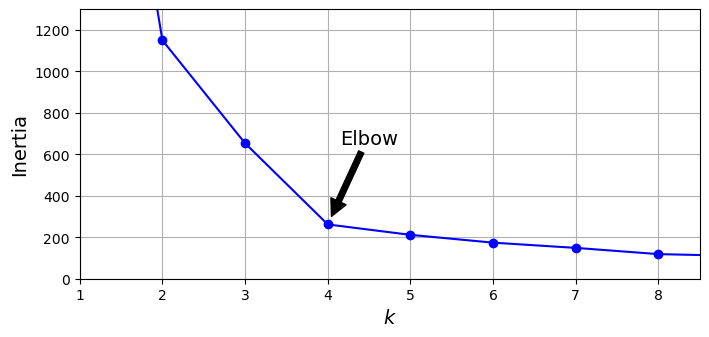

In [23]:
# extra code – this cell generates Figure 8–8

kmeans_per_k = [KMeans(n_clusters=k, random_state=43).fit(X)
                for k in range(1, 10)]
inertias = [model.inertia_ for model in kmeans_per_k]

plt.figure(figsize=(8, 3.5))
plt.plot(range(1, 10), inertias, "bo-")
plt.xlabel("$k$")
plt.ylabel("Inertia")
plt.annotate("", xy=(4, inertias[3]), xytext=(4.45, 650),
             arrowprops=dict(facecolor='black', shrink=0.1))
plt.text(4.5, 650, "Elbow", horizontalalignment="center")
plt.axis([1, 8.5, 0, 1300])
plt.grid()

plt.show()

이유는 군집이 네 개보다 작으면 별로이고, 4개보다 많아도 훨씬 좋아진다고 보기 어렵기 때문이다.
하지만 4개의 군집으로 구성하려 하면 아래 그림과 같이 왼쪽 하단 두 개의 군집이 하나의 군집으로 처리될 수 있기에
가장 좋은 군집화라고 말하기 어렵다.

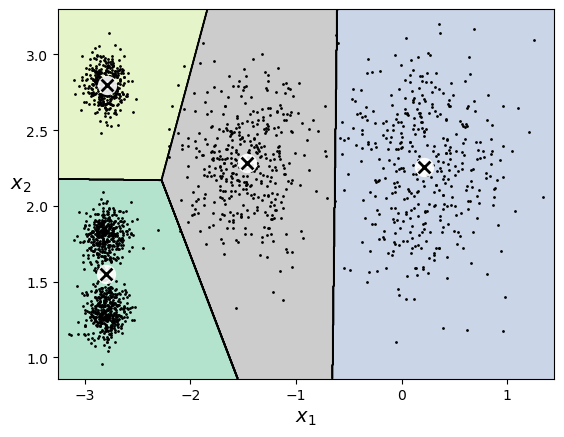

In [24]:
# extra code
plot_decision_boundaries(kmeans_per_k[4 - 1], X)
plt.show()

**방법 2: 실루엣 점수와 군집수**

**실루엣 점수**<font size='2'>silhouette score</font>는 모든 샘플의 실루엣 계수의 평균값이다.
샘플의 **실루엣 계수**<font size='2'>silhouette coefficient</font>는 다음 식으로 계산된다.

$$
\frac{b - a}{\max(a, b)}
$$

- $a$: 해당 샘플과 동일한 군집에 속하는 다른 샘플들 사이의 거리의 평균값
- $b$: 해당 샘플이 속하지 않은 각 군집에 대해 계산한 평균 거리 중 최솟값.
  즉, 평균 거리가 가장 작은 다른 군집과 해당 샘플 사이의 평균 거리

실루엣 계수는 군집 수가 2개 이상이고 샘플 수보다 작을 때 정의되며,
-1과 1 사이의 값을 갖는다.

* 1에 가까운 값: 동일 군집의 샘플들과는 가깝고 다른 군집들과는 멀리 떨어져 있음을 의미한다.
* 0에 가까운 값: 해당 샘플이 두 군집의 경계 부근에 있거나 군집들이 서로 겹쳐 있음을 의미한다.
* -1에 가까운 값: 해당 샘플이 현재 군집보다 다른 군집에 더 가까워 잘못 할당되었을 가능성이 높음을 의미한다.

In [25]:
from sklearn.metrics import silhouette_score

silhouette_score(X, kmeans.labels_)

0.655517642572828

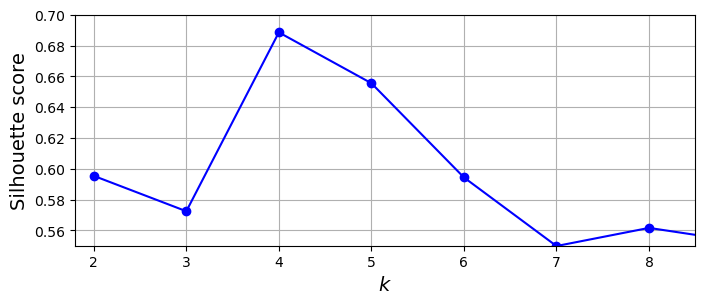

In [26]:
# extra code – this cell generates Figure 8–9

silhouette_scores = [silhouette_score(X, model.labels_)
                     for model in kmeans_per_k[1:]]

plt.figure(figsize=(8, 3))
plt.plot(range(2, 10), silhouette_scores, "bo-")
plt.xlabel("$k$")
plt.ylabel("Silhouette score")
plt.axis([1.8, 8.5, 0.55, 0.7])
plt.grid()

plt.show()

k=4가 여전히 매우 좋아 보인다. 
하지만 관성의 경우와는 달리 k=5도 역시 꽤 좋다는 것을 알 수 있다. 

**방법 3: 실루엣 다이어그램과 군집수**

**실루엣 다이어그램**은 군집별로 샘플의 실루엣 계수를 모아 표시한 그래프다.
군집별로 실루엣 계수를 정렬하여 그리면 아래 그림처럼 여러 개의 칼날 모양이 형성된다.

- 칼날 두께: 해당 군집에 포함된 샘플 수
- 칼날의 가로 길이: 해당 샘플의 실루엣 계수
- 빨간 파선: 실루엣 점수

좋은 군집화 결과에서는 실루엣 점수가 크고, 대부분의 샘플이 충분히 큰 양의 실루엣 계수를 갖는다.
반대로 실루엣 계수가 0에 가까운 샘플이 많으면 군집 경계가 불분명하다는 뜻이며,
음수인 샘플이 많으면 일부 샘플이 적절하지 않은 군집에 할당되었을 가능성이 높다.

칼날의 두께는 군집별 크기를 비교하는 데 사용할 수 있다.
데이터의 실제 군집들이 비슷한 크기라고 기대되는 경우에는,
칼날 두께가 크게 불균형한 모델보다 비슷한 두께를 보이는 모델이 더 자연스러울 수 있다.
아래 데이터셋에서는 이런 기준을 함께 고려할 때 `k=5`인 모델이 가장 적절해 보인다.

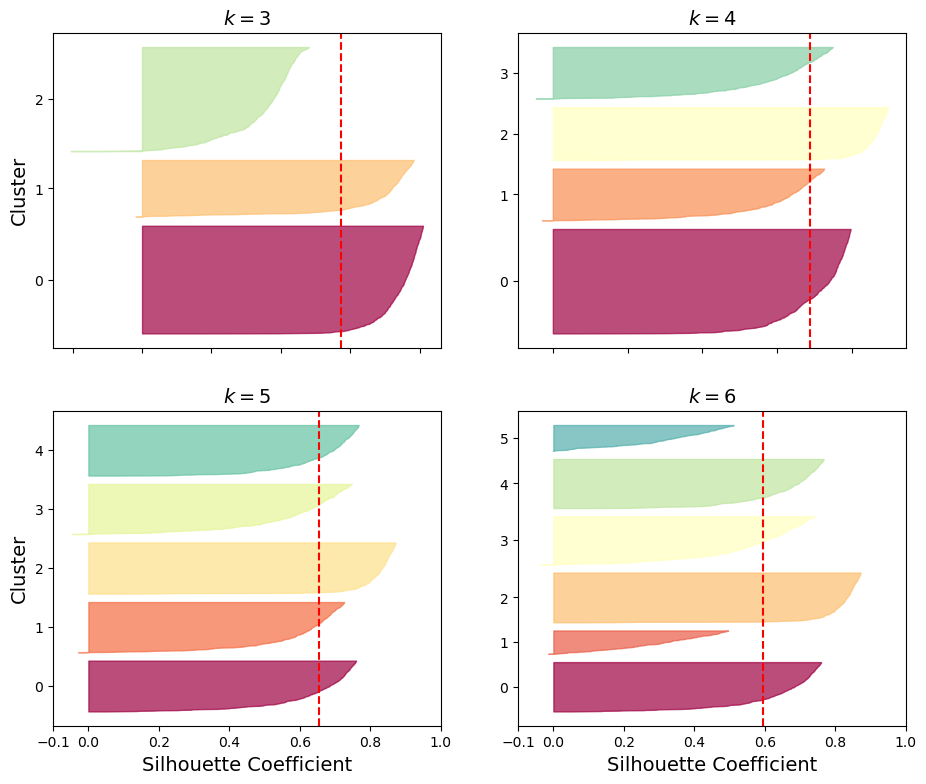

In [27]:
# extra code – this cell generates Figure 8–10

from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter

plt.figure(figsize=(11, 9))

for k in (3, 4, 5, 6):
    plt.subplot(2, 2, k - 2)

    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)

    padding = len(X) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = plt.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    if k in (3, 5):
        plt.ylabel("Cluster")

    if k in (5, 6):
        plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xlabel("Silhouette Coefficient")
    else:
        plt.tick_params(labelbottom=False)

    plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title(f"$k={k}$")


plt.show()

### k-평균 한계

첫째, 초기 센트로이드의 선택에 따라 서로 다른 군집화 결과가 나올 수 있다.
따라서 좋은 결과를 얻기 위해 여러 초기화를 실행하거나 k-평균++와 같은 초기화 방식을 활용한다.

둘째, 군집수 $k$를 미리 지정해야 한다.

셋째, k-평균은 군집의 크기와 밀도가 서로 비슷하고, 군집이 구형에 가까울 때 잘 작동한다.
따라서 군집의 크기나 밀도가 크게 다르거나, 길게 늘어진 비구형 군집에서는 적절하지 않은 결과를 낼 수 있다.
예를 들어 아래 그림의 데이터는 군집이 길게 늘어진 형태이므로,
양쪽 그림에 보이는 k-평균 군집화 결과 모두 적절하지 않다.
특히 오른쪽 결과는 관성이 왼쪽보다 작지만 실제 군집 구조는 더 나쁘게 반영한다.
이는 관성이 작다는 사실만으로 군집화가 의미 있게 구성되었다고 판단할 수 없음을 보여준다.

데이터가 여러 가우스 분포의 혼합으로 잘 설명되는 타원형 군집으로 구성되어 있다면,
이어서 소개하는 가우스 혼합 모델(GMM)이 k-평균보다 더 적합할 수 있다.

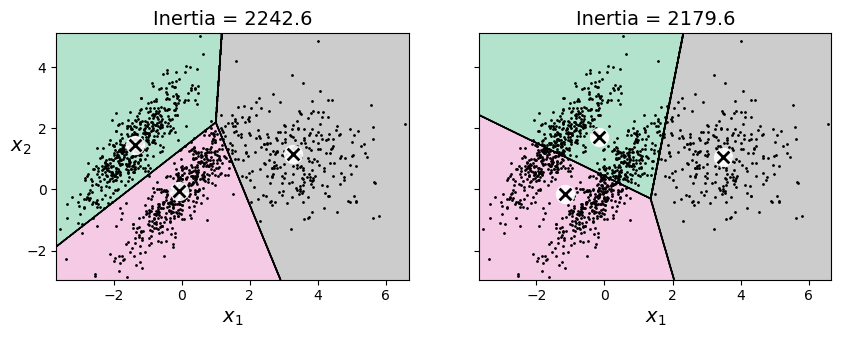

In [28]:
# extra code – this cell generates Figure 8–11

X1, y1 = make_blobs(n_samples=1000, centers=((4, -4), (0, 0)), random_state=42)
X1 = X1.dot(np.array([[0.374, 0.95], [0.732, 0.598]]))
X2, y2 = make_blobs(n_samples=250, centers=1, random_state=42)
X2 = X2 + [6, -8]
X = np.r_[X1, X2]
y = np.r_[y1, y2]

kmeans_good = KMeans(n_clusters=3,
                     init=np.array([[-1.5, 2.5], [0.5, 0], [4, 0]]),
                     random_state=42)
kmeans_bad = KMeans(n_clusters=3, n_init=10, random_state=42)
kmeans_good.fit(X)
kmeans_bad.fit(X)

plt.figure(figsize=(10, 3.2))

plt.subplot(121)
plot_decision_boundaries(kmeans_good, X)
plt.title(f"Inertia = {kmeans_good.inertia_:.1f}")

plt.subplot(122)
plot_decision_boundaries(kmeans_bad, X, show_ylabels=False)
plt.title(f"Inertia = {kmeans_bad.inertia_:.1f}")


plt.show()

## DBSCAN

DBSCAN(Density-Based Spatial Clustering of Applications with Noise) 알고리즘은
밀도가 높은 샘플들이 서로 연결된 영역을 군집으로 지정한다.
알고리즘이 작동하는 방식은 다음과 같다.

- 각 샘플에 대해 $\varepsilon$-**이웃**에 자신을 포함하여 몇 개의 샘플이 있는지 확인한다.
  $\varepsilon$-**이웃**은 샘플을 중심으로 반경이 $\varepsilon$인 영역을 가리킨다.
- 어떤 샘플의 $\varepsilon$-이웃 안에 `min_samples` 개수 이상의 샘플이 존재한다면 해당 샘플을
  **핵심 샘플**<font size='2'>core instance</font>이라 부른다.
- 핵심 샘플의 $\varepsilon$-이웃에 포함된 샘플은 모두 동일한 군집에 속한다.
  이웃에 포함된 다른 샘플 또한 핵심 샘플이라면, 그 샘플의 $\varepsilon$-이웃에
  포함된 샘플도 모두 동일한 군집에 속한다.
  즉, 군집은 서로 연결된 핵심 샘플들과 그 이웃 샘플들로 이뤄진다.
- 핵심 샘플의 $\varepsilon$-이웃에 포함되지만 자신은 핵심 샘플이 아닌 샘플은
  해당 군집의 경계 샘플로 간주된다.
- 어떤 핵심 샘플로부터도 $\varepsilon$-이웃의 연쇄를 통해 도달할 수 없는 샘플은
  가까운 샘플이 있더라도 이상치, 또는 잡음으로 간주된다.

DBSCAN 알고리즘은 군집들이 밀도가 낮은 영역으로 서로 구분될 때 잘 작동한다.

### 사이킷런 DBSCAN 모델

**군집 레이블**

DBSCAN 모델이 찾은 군집 레이블 정보는 0, 1, 2, ... 등 정수 인덱스로 표기되며
`labels_` 속성에 저장된다.
군집 레이블이 -1로 표기되는 경우는 이상치를 의미한다.

In [29]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=1000, noise=0.05, random_state=42)
dbscan = DBSCAN(eps=0.05, min_samples=5)
dbscan.fit(X)

,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",0.05
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",5
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [30]:
dbscan.labels_[:10]

array([ 0,  2, -1, -1,  1,  0,  0,  0,  2,  5])

**핵심 샘플**

핵심 샘플들의 행 인덱스는 `core_sample_indices_` 속성에 저장된다.

In [31]:
dbscan.core_sample_indices_[:10]

array([ 0,  4,  5,  6,  7,  8, 10, 11, 12, 13])

핵심 샘플로 구성된 데이터셋은 `components_` 속성에 저장된다.

In [32]:
dbscan.components_

array([[-0.02137124,  0.40618608],
       [-0.84192557,  0.53058695],
       [ 0.58930337, -0.32137599],
       ...,
       [ 1.66258462, -0.3079193 ],
       [-0.94355873,  0.3278936 ],
       [ 0.79419406,  0.60777171]], shape=(808, 2))

**군집화 결과**

아래 그림은 $\varepsilon$-이웃의 반경을 0.05로 할 때(왼쪽)와 0.2로 할 때(오른쪽)의 차이를 보여준다.

| 특징| 왼쪽 그림(이웃 반경 0.05) | 오른쪽 그림(이웃 반경 0.2) |
| :---: | :---: | :---: |
| 군집수 | 2개 초과 | 2개 |
| 이상치(빨강 &#128473;) | 많음 | 없음 |

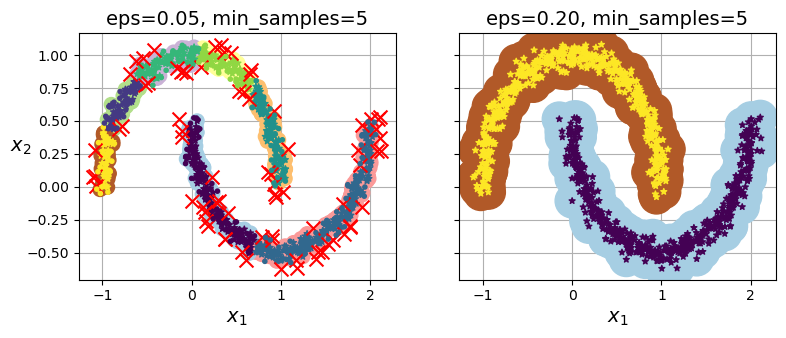

In [33]:
def plot_dbscan(dbscan, X, size, show_xlabels=True, show_ylabels=True):
    core_mask = np.zeros_like(dbscan.labels_, dtype=bool)
    core_mask[dbscan.core_sample_indices_] = True
    anomalies_mask = dbscan.labels_ == -1
    non_core_mask = ~(core_mask | anomalies_mask)

    cores = dbscan.components_
    anomalies = X[anomalies_mask]
    non_cores = X[non_core_mask]

    plt.scatter(cores[:, 0], cores[:, 1],
                c=dbscan.labels_[core_mask], marker='o', s=size, cmap="Paired")
    plt.scatter(cores[:, 0], cores[:, 1], marker='*', s=20,
                c=dbscan.labels_[core_mask])
    plt.scatter(anomalies[:, 0], anomalies[:, 1],
                c="r", marker="x", s=100)
    plt.scatter(non_cores[:, 0], non_cores[:, 1],
                c=dbscan.labels_[non_core_mask], marker=".")
    if show_xlabels:
        plt.xlabel("$x_1$")
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", rotation=0)
    else:
        plt.tick_params(labelleft=False)
    plt.title(f"eps={dbscan.eps:.2f}, min_samples={dbscan.min_samples}")
    plt.grid()
    plt.gca().set_axisbelow(True)

dbscan2 = DBSCAN(eps=0.2)
dbscan2.fit(X)

plt.figure(figsize=(9, 3.2))

plt.subplot(121)
plot_dbscan(dbscan, X, size=100)

plt.subplot(122)
plot_dbscan(dbscan2, X, size=600, show_ylabels=False)


plt.show()

### DBSCAN 활용

DBSCAN 모델은 `predict()` 메서드를 지원하지 않는다. 즉, 새로운 샘플에 대한 군집 예측을 지원하지 않는다.
`predict()` 메서드를 지원하지 않는 이유는 훈련 후 새 샘플을 어느 군집에 배정할지에 대한
규칙이 DBSCAN 알고리즘 자체에 정해져 있지 않기 때문이다.
반면에 `fit_predict()` 메서드는 지원하며, 훈련셋에 대한 군집 인덱스를 반환한다.

하지만 실제 활용에서는 새 샘플이 기존 군집 중 어느 군집과 가장 비슷한지 알고 싶을 수 있다.
이 경우 용도에 맞는 별도의 분류 전략을 선택할 수 있다.
예를 들어 `KNeighborsClassifier`는 새 샘플과 가까운 훈련 샘플들의 레이블을 참고하여
새 샘플의 레이블을 예측하는 분류 모델이다.
아래 코드는 이 모델을 `dbscan`이 만든 군집 레이블을 이용해 훈련시킨다.

- `dbscan`: `eps=0.2`로 훈련된 모델을 가리킨다. 즉, 위 오른쪽 그림에서 사용된 DBSCAN 모델이다.

In [34]:
dbscan = dbscan2  # extra code – the text says we now use eps=0.2

In [35]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=50)
knn.fit(dbscan.components_, dbscan.labels_[dbscan.core_sample_indices_])

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",50
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


**활용 1: 새로운 데이터 군집 분류**

이제 `knn`은 `dbscan`이 만든 군집 레이블을 기준으로,
새로운 데이터 샘플이 기존 군집 중 어느 군집에 가까운지 예측할 수 있다.

예를 들어, `dbscan`으로 기존 고객을 구매 패턴에 따라 여러 군집으로 나누었다고 가정하자.
이후 새로운 고객 데이터가 들어오면, 앞서 훈련한 `knn` 모델을 이용해
이 고객이 기존 군집 중 어느 군집과 가장 비슷한지 예측할 수 있다.
또한 `predict_proba()`를 이용하면 특정 군집에 뚜렷하게 가까운지,
아니면 여러 군집 사이에 애매하게 위치하는지도 함께 확인할 수 있다.

In [36]:
X_new = np.array([[-0.5, 0], [0, 0.5], [1, -0.1], [2, 1]])
knn.predict(X_new)

array([1, 0, 1, 0])

In [37]:
knn.predict_proba(X_new)

array([[0.18, 0.82],
       [1.  , 0.  ],
       [0.12, 0.88],
       [1.  , 0.  ]])

**활용 2: 결정 경계**

아래 그림은 `knn` 모델을 이용하여 두 개의 그룹을 분류하는 결정 경계를 보여준다.
파랑 덧셈 기호 <font color='blue' size='4'>&#43;</font>는 이전 코드에서 지정한 `X_new` 어레이에 포함된 4개의 새로운 데이터 샘플을 가리킨다.

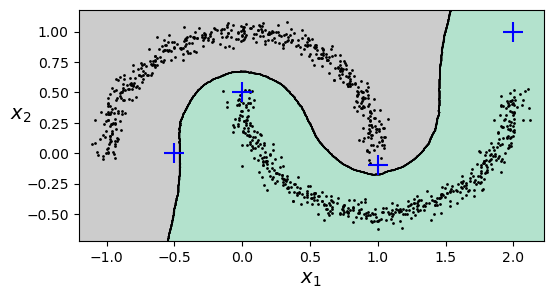

In [38]:
plt.figure(figsize=(6, 3))
plot_decision_boundaries(knn, X, show_centroids=False)
plt.scatter(X_new[:, 0], X_new[:, 1], c="b", marker="+", s=200, zorder=10)

plt.show()

4개의 샘플 중에 양 끝에 있는 두 샘플은 다른 데이터들로부터 너무 멀리 떨어져 있기 때문에 이상치로 간주된다.
실제로 `dbscan.labels_` 에 저장된 두 샘플의 군집 인덱스가 -1이다.

In [39]:
y_dist, y_pred_idx = knn.kneighbors(X_new, n_neighbors=1)
y_pred = dbscan.labels_[dbscan.core_sample_indices_][y_pred_idx]
y_pred[y_dist > 0.2] = -1
y_pred.ravel()

array([-1,  0,  1, -1])

## 가우스 혼합 모델

아래 코드는 세 개의 가우스 분포가 혼합된 데이터셋에 GMM을 훈련한다. GMM은 각 가우스 성분의 평균, 공분산, 혼합 비율을 추정한다.

- `GaussianMixture`: 가우스 혼합 모델
- `n_components`: 모델이 가정하는 가우스 분포의 개수, 즉 군집의 개수
- `n_init`: 서로 다른 초기값으로 학습을 반복하는 횟수. 아래 모델은 10번 학습한 결과 중 데이터에 가장 잘 맞는 결과를 선택한다.

앞서 사용한 데이터셋을 다시 훈련에 활용한다.

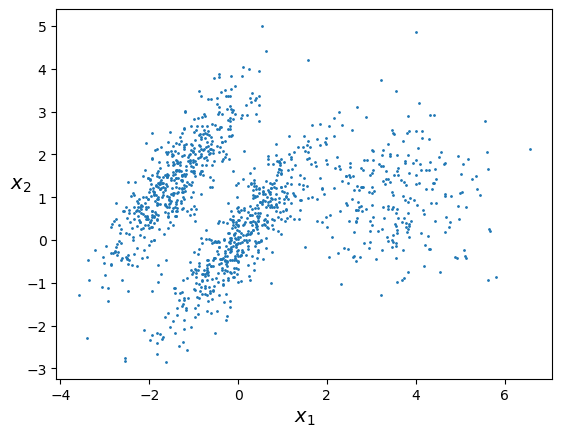

In [95]:
X1, y1 = make_blobs(n_samples=1000, centers=((4, -4), (0, 0)), random_state=42)
X1 = X1.dot(np.array([[0.374, 0.95], [0.732, 0.598]]))
X2, y2 = make_blobs(n_samples=250, centers=1, random_state=42)
X2 = X2 + [6, -8]
X = np.r_[X1, X2]
y = np.r_[y1, y2]

plot_clusters(X)

가우스 혼합 모델을 위 데이터셋을 이용하여 훈련한다.

In [41]:
from sklearn.mixture import GaussianMixture

gm = GaussianMixture(n_components=3, n_init=10, random_state=42)
gm.fit(X)

,"n_components n_components: int, default=1The number of mixture components.",3
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",10
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


- 군집별 가중치(군집별 샘플 비율)

In [42]:
gm.weights_

array([0.40005972, 0.20961444, 0.39032584])

- 군집별 평균값

In [43]:
gm.means_

array([[-1.40764129,  1.42712848],
       [ 3.39947665,  1.05931088],
       [ 0.05145113,  0.07534576]])

- 군집별 공분산

In [44]:
gm.covariances_

array([[[ 0.63478217,  0.72970097],
        [ 0.72970097,  1.16094925]],

       [[ 1.14740131, -0.03271106],
        [-0.03271106,  0.95498333]],

       [[ 0.68825143,  0.79617956],
        [ 0.79617956,  1.21242183]]])

- 군집화 성공 여부

In [45]:
gm.converged_

True

- 군집화 성공에 필요한 초기화 횟수

In [46]:
gm.n_iter_

4

- 새로운 샘플에 대한 군집 예측

In [47]:
gm.predict(X)

array([2, 2, 0, ..., 1, 1, 1], shape=(1250,))

- 새로운 샘플에 대해 각 군집에 속할 상대적 확률 계산

In [48]:
gm.predict_proba(X).round(3)

array([[0.   , 0.023, 0.977],
       [0.001, 0.016, 0.983],
       [1.   , 0.   , 0.   ],
       ...,
       [0.   , 1.   , 0.   ],
       [0.   , 1.   , 0.   ],
       [0.   , 1.   , 0.   ]], shape=(1250, 3))

**생성 모델**

가우스 혼합 모델은 생성 모델이다.
즉, 새로운 데이터 샘플을 군집 라벨과 함께 생성할 수 있다.
아래 코드는 6개의 새로운 샘플을 군집 정보와 함께 생성한다.

In [49]:
X_new, y_new = gm.sample(6)
X_new

array([[-2.32491052,  1.04752548],
       [-1.16654983,  1.62795173],
       [ 1.84860618,  2.07374016],
       [ 3.98304484,  1.49869936],
       [ 3.8163406 ,  0.53038367],
       [ 0.38079484, -0.56239369]])

새로 생성된 샘플은 군집 크기에 비례해서 생성된다.

In [50]:
y_new

array([0, 0, 1, 1, 1, 2])

**데이터 확률 밀도 측정**

`score_samples()` 메서드는 주어진 위치에서의 데이터 확률 밀도의 로그값을 측정한다.

In [51]:
gm.score_samples(X).round(2)

array([-2.61, -3.57, -3.33, ..., -3.51, -4.4 , -3.81], shape=(1250,))

학습된 모델을 이용하여 아래 그림을 그릴 수 있다.

- 군집 평균: &#128473; 표시
- 결정 경계: 빨강 파선
- 밀도 등고선: 진한 파랑색에 가까울 수록 데이터 밀도 높음

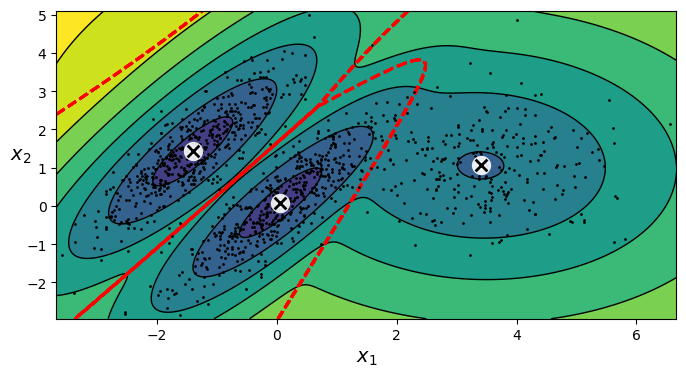

In [52]:
# extra code – this cell generates Figure 8–16

from matplotlib.colors import LogNorm

def plot_gaussian_mixture(clusterer, X, resolution=1000, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = -clusterer.score_samples(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z,
                 norm=LogNorm(vmin=1.0, vmax=30.0),
                 levels=np.logspace(0, 2, 12))
    plt.contour(xx, yy, Z,
                norm=LogNorm(vmin=1.0, vmax=30.0),
                levels=np.logspace(0, 2, 12),
                linewidths=1, colors='k')

    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contour(xx, yy, Z,
                linewidths=2, colors='r', linestyles='dashed')

    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)
    plot_centroids(clusterer.means_, clusterer.weights_)

    plt.xlabel("$x_1$")
    if show_ylabels:
        plt.ylabel("$x_2$", rotation=0)
    else:
        plt.tick_params(labelleft=False)

plt.figure(figsize=(8, 4))

plot_gaussian_mixture(gm, X)


plt.show()

**GMM 모델의 공분산 유형**

데이터셋의 차원이 높거나 군집 수가 많고 샘플 수가 적으면 공분산을 정확하게 추정하기 어렵다. 이때 `covariance_type`으로 공분산의 형태를 제한하여 추정할 파라미터 수를 줄일 수 있다.

- `full`: 군집마다 형태, 크기, 방향이 다른 타원형을 허용한다. 기본값이다.
- `spherical`: 모든 군집을 원형으로 가정한다. 원의 크기는 군집마다 다를 수 있다.
- `diag`: 타원의 축이 좌표축과 평행하다고 가정한다. 형태와 크기는 군집마다 다를 수 있다.
- `tied`: 모든 군집이 동일한 형태, 크기, 방향을 갖는다고 가정한다.

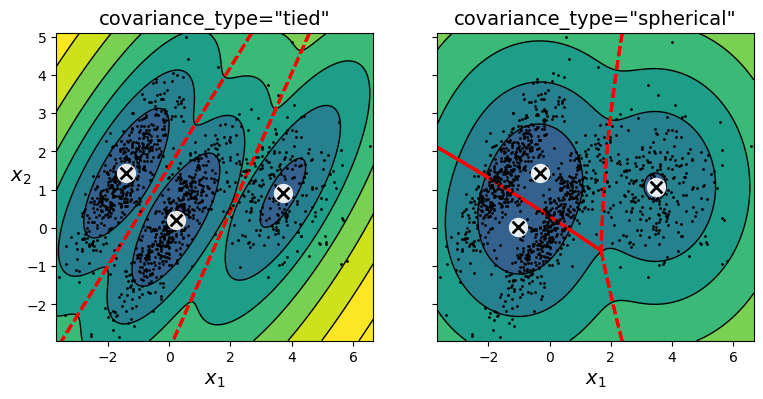

In [53]:
# extra code – this cell generates Figure 8–17

gm_full = GaussianMixture(n_components=3, n_init=10,
                          covariance_type="full", random_state=42)
gm_tied = GaussianMixture(n_components=3, n_init=10,
                          covariance_type="tied", random_state=42)
gm_spherical = GaussianMixture(n_components=3, n_init=10,
                               covariance_type="spherical", random_state=42)
gm_diag = GaussianMixture(n_components=3, n_init=10,
                          covariance_type="diag", random_state=42)
gm_full.fit(X)
gm_tied.fit(X)
gm_spherical.fit(X)
gm_diag.fit(X)

def compare_gaussian_mixtures(gm1, gm2, X):
    plt.figure(figsize=(9, 4))

    plt.subplot(121)
    plot_gaussian_mixture(gm1, X)
    plt.title(f'covariance_type="{gm1.covariance_type}"')

    plt.subplot(122)
    plot_gaussian_mixture(gm2, X, show_ylabels=False)
    plt.title(f'covariance_type="{gm2.covariance_type}"')

compare_gaussian_mixtures(gm_tied, gm_spherical, X)


plt.show()

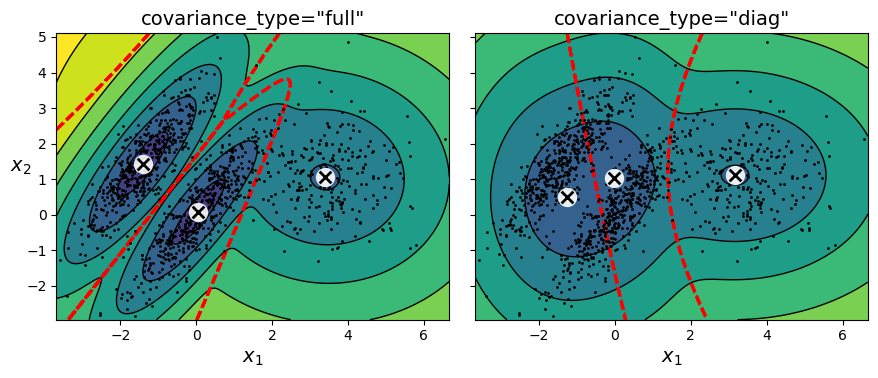

In [54]:
# extra code – comparing covariance_type="full" and covariance_type="diag"
compare_gaussian_mixtures(gm_full, gm_diag, X)
plt.tight_layout()
plt.show()

### 이상치 탐지

데이터 샘플의 로그 확률밀도가 지정된 임곗값보다 낮으면 해당 샘플을 이상치로 간주할 수 있다. 임곗값은 상황에 따라 다르게 지정한다.

예를 들어 제품의 결함 비율이 약 2%라고 알려진 경우, 훈련 샘플 가운데 로그 확률밀도가 가장 낮은 하위 2%를 이상치 후보로 정할 수 있다. 이는 확률밀도 값이 2% 이하라는 의미가 아니라, 밀도 순위가 하위 2%라는 뜻이다. 탐지된 결함 비율이 예상보다 낮거나 높다면 백분위 기준을 조정해야 한다.

`score_samples()` 메서드는 각 데이터 샘플의 로그 확률밀도를 계산한다. 
아래 그림에서는 로그 확률밀도가 하위 2%에 속하는 샘플을
빨간 별표(<span style="color:red;">&#x2605;</span>)로 표시한다.

In [55]:
densities = gm.score_samples(X)
density_threshold = np.percentile(densities, 2)
anomalies = X[densities < density_threshold]

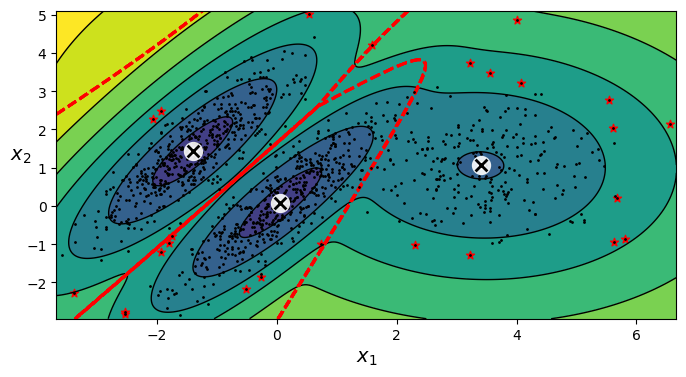

In [56]:
# extra code – this cell generates Figure 8–18

plt.figure(figsize=(8, 4))

plot_gaussian_mixture(gm, X)
plt.scatter(anomalies[:, 0], anomalies[:, 1], color='r', marker='*')
plt.ylim(top=5.1)


plt.show()

### 군집수 지정

적절한 군집 수를 미리 지정해야 하지만, 일반적으로 최적의 군집 수를
결정하는 방식은 알려져 있지 않다.
GMM이 예측한 군집 레이블로 실루엣 점수를 계산할 수도 있지만, 모델의 데이터 적합도와 복잡도를 함께 평가하려면 **정보 기준**<font size='2'>information criterion</font>을 사용할 수 있다. 일반적으로 정보 기준을 가장 작게 만드는 군집 수를 선택한다.

대표적인 정보 기준은 다음과 같다. 두 값 모두 작을수록 좋은 모델로 평가한다.

- BIC<font size='2'>Bayesian information criterion</font>

  $$\log(m)\,p-2\log(\hat L)$$

- AIC<font size='2'>Akaike information criterion</font>

  $$2p-2\log(\hat L)$$

각 기호의 의미는 다음과 같다.

- $m$: 데이터셋의 샘플 수
- $p$: 모델이 학습하는 파라미터 수
- $\hat L$: 학습된 모델이 데이터에 얼마나 잘 들어맞는지를 나타내는 값의 최댓값

두 기준 모두 데이터에 잘 맞으면서 지나치게 복잡하지 않은 모델을 선택하기 위한 것이다.

- 혼합 비율, 평균, 공분산 등 모델이 학습해야 하는 값이 많을수록 기준값이 높아진다.
- 모델이 데이터의 분포를 잘 설명할수록 기준값이 낮아진다.

**군집 수와 정보 기준**

아래 그림은 군집 수 \(k\)에 따른 AIC와 BIC를 보여준다. 두 기준 모두 \(k=3\)에서 가장 작으므로 군집 수로 3을 선택할 수 있다.

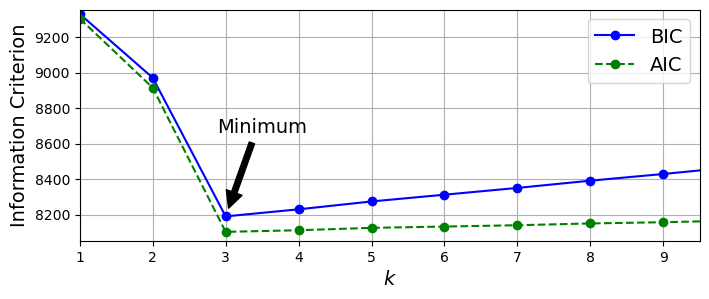

In [57]:
# extra code – this cell generates Figure 8–20

gms_per_k = [GaussianMixture(n_components=k, n_init=10, random_state=42).fit(X)
             for k in range(1, 11)]
bics = [model.bic(X) for model in gms_per_k]
aics = [model.aic(X) for model in gms_per_k]

plt.figure(figsize=(8, 3))
plt.plot(range(1, 11), bics, "bo-", label="BIC")
plt.plot(range(1, 11), aics, "go--", label="AIC")
plt.xlabel("$k$")
plt.ylabel("Information Criterion")
plt.axis([1, 9.5, min(aics) - 50, max(aics) + 50])
plt.annotate("", xy=(3, bics[2]), xytext=(3.4, 8650),
             arrowprops=dict(facecolor='black', shrink=0.1))
plt.text(3.5, 8660, "Minimum", horizontalalignment="center")
plt.legend()
plt.grid()

plt.show()

### 베이즈 가우스 혼합 모델

`BayesianGaussianMixture` 모델은 군집 수의 상한을 지정한 뒤, 불필요한 군집의 가중치를 매우 작게 만들어 실제로 사용되는 군집 수를 줄인다.

- `n_components` 하이퍼파라미터에 예상되는 군집 수보다 충분히 큰 값을 지정한다. 
- 학습 과정에서 불필요한 군집의 가중치는 0에 가까워지므로 사실상 무시된다. 

다음 코드는 군집 수의 상한을 10으로 지정하여 베이즈 가우스 혼합 모델을 훈련한다.

In [58]:
from sklearn.mixture import BayesianGaussianMixture

bgm = BayesianGaussianMixture(n_components=10, n_init=10, max_iter=500,
                              random_state=42)
bgm.fit(X)

,"n_components n_components: int, default=1The number of mixture components. Depending on the data and the valueof the `weight_concentration_prior` the model can decide to not useall the components by setting some component `weights_` to values veryclose to zero. The number of effective components is therefore smallerthan n_components.",10
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full' (each component has its own general covariance matrix),- 'tied' (all components share the same general covariance matrix),- 'diag' (each component has its own diagonal covariance matrix),- 'spherical' (each component has its own single variance).",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain on the likelihood (of the training data withrespect to the model) is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",500
,"n_init n_init: int, default=1The number of initializations to perform. The result with the highestlower bound value on the likelihood is kept.",10
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and thecovariances. String must be one of:- 'kmeans': responsibilities are initialized using kmeans.- 'k-means++': use the k-means++ method to initialize.- 'random': responsibilities are initialized randomly.- 'random_from_data': initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weight_concentration_prior_type weight_concentration_prior_type: {'dirichlet_process', 'dirichlet_distribution'}, default='dirichlet_process'String describing the type of the weight concentration prior.",'dirichlet_process'
,"weight_concentration_prior weight_concentration_prior: float or None, default=NoneThe dirichlet concentration of each component on the weightdistribution (Dirichlet). This is commonly called gamma in theliterature. The higher concentration puts more mass inthe center and will lead to more components being active, while a lowerconcentration parameter will lead to more mass at the edge of themixture weights simplex. The value of the parameter must be greaterthan 0. If it is None, it's set to ``1. / n_components``.",None
,"mean_precision_prior mean_precision_prior: float or None, default=NoneThe precision prior on the mean distribution (Gaussian).Controls the extent of where means can be placed. Largervalues concentrate the cluster means around `mean_prior`.The value of the parameter must be greater than 0.If it is None, it is set to 1.",None
,"mean_prior mean_prior: array-like, shape (n_features,), default=NoneThe prior on the mean distribution (Gaussian).If it is None, it is set to the mean of X.",None


훈련된 모델의 `weights_` 속성에 각 군집의 가중치가 아래 형식으로 계산된다.
세 군집에는 약 4:2:4의 비율로 가중치가 부여되고, 
나머지 일곱 군집의 가중치는 소수점 셋째 자리에서 반올림하면 0으로 표시될 만큼 작다.

In [59]:
bgm.weights_.round(2)

array([0.4 , 0.21, 0.39, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ])

찾아진 3개의 군집은 다음과 같다.

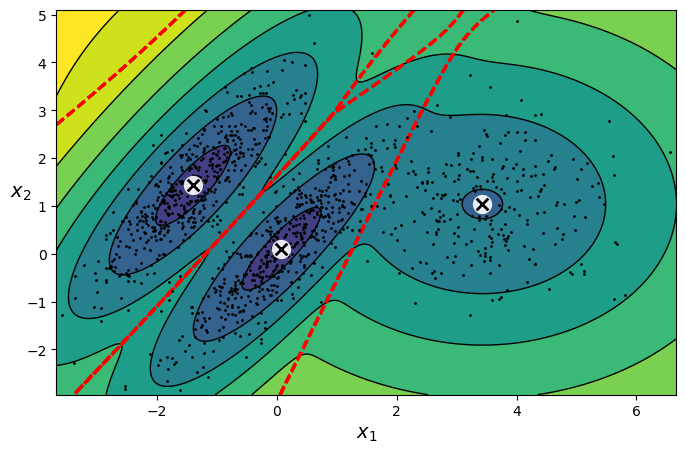

In [60]:
# extra code – this figure is almost identical to Figure 8–16
plt.figure(figsize=(8, 5))
plot_gaussian_mixture(bgm, X)
plt.show()

### 가우스 혼합 모델의 장단점

GMM은 타원형 군집으로 이루어진 데이터셋에서 잘 작동한다. 반면 타원형이 아닌 군집은 하나의 자연스러운 군집을 여러 가우스 분포로 나누어 표현할 수 있으므로, 예상과 다른 개수나 모양의 군집이 만들어질 수 있다.

예를 들어 왼쪽의 초승달 데이터셋에 베이즈 가우스 혼합 모델을 적용하면, 오른쪽 그림처럼 초승달 모양을 여러 타원형 군집으로 나누어 표현한다. 따라서 실제 군집 수보다 많은 군집을 사용하는 것처럼 보일 수 있다.

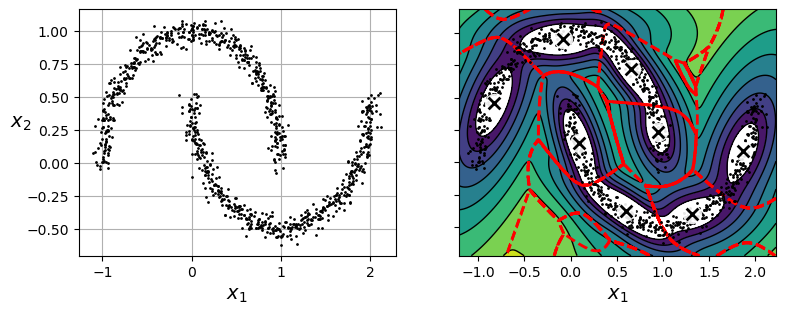

In [61]:
# extra code – this cell generates Figure 8–21

X_moons, y_moons = make_moons(n_samples=1000, noise=0.05, random_state=42)

bgm = BayesianGaussianMixture(n_components=10, n_init=10, max_iter=500, random_state=42)
bgm.fit(X_moons)

plt.figure(figsize=(9, 3.2))

plt.subplot(121)
plot_data(X_moons)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$", rotation=0)
plt.grid()

plt.subplot(122)
plot_gaussian_mixture(bgm, X_moons, show_ylabels=False)


plt.show()

## 연습문제

**문제 1: 올리베티 얼굴 데이터셋 군집화**

올리베티 얼굴 데이터셋은 40명의 얼굴을 각각 10번씩 촬영한 400개의 흑백 이미지로 구성된다. 각 이미지의 크기는 64 × 64 픽셀이며, 길이가 4,096인 1차원 벡터로 저장된다. 일반적인 학습 목표는 각 이미지에 담긴 인물을 예측하는 것이다.

`sklearn.datasets.fetch_olivetti_faces()` 함수를 이용하여 데이터셋을 불러온다.

In [62]:
from sklearn.datasets import fetch_olivetti_faces

olivetti = fetch_olivetti_faces()

In [63]:
print(olivetti.DESCR)

.. _olivetti_faces_dataset:

The Olivetti faces dataset
--------------------------

`This dataset contains a set of face images`_ taken between April 1992 and
April 1994 at AT&T Laboratories Cambridge. The
:func:`sklearn.datasets.fetch_olivetti_faces` function is the data
fetching / caching function that downloads the data
archive from AT&T.

.. _This dataset contains a set of face images: https://cam-orl.co.uk/facedatabase.html

As described on the original website:

    There are ten different images of each of 40 distinct subjects. For some
    subjects, the images were taken at different times, varying the lighting,
    facial expressions (open / closed eyes, smiling / not smiling) and facial
    details (glasses / no glasses). All the images were taken against a dark
    homogeneous background with the subjects in an upright, frontal position
    (with tolerance for some side movement).

**Data Set Characteristics:**

=================   =====================
Classes              

In [64]:
olivetti.target

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  5,
        5,  5,  5,  5,  5,  5,  5,  5,  5,  6,  6,  6,  6,  6,  6,  6,  6,
        6,  6,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  8,  8,  8,  8,  8,
        8,  8,  8,  8,  8,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9, 10, 10,
       10, 10, 10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 13, 13, 13, 13, 13, 13,
       13, 13, 13, 13, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 15, 15, 15,
       15, 15, 15, 15, 15, 15, 15, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 18, 18, 18, 18, 18, 18, 18,
       18, 18, 18, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 20, 20, 20, 20,
       20, 20, 20, 20, 20, 20, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 22,
       22, 22, 22, 22, 22

데이터셋을 훈련셋, 검증셋, 테스트셋으로 나눈다. 데이터셋의 특성은 이미 0과 1 사이로 스케일링되어 있다. 데이터셋이 작으므로 각 데이터셋에 인물별 이미지가 같은 비율로 포함되도록 계층적 샘플링을 사용한다.

In [65]:
from sklearn.model_selection import StratifiedShuffleSplit

strat_split = StratifiedShuffleSplit(n_splits=1, test_size=40, random_state=42)
train_valid_idx, test_idx = next(strat_split.split(olivetti.data,
                                                   olivetti.target))
X_train_valid = olivetti.data[train_valid_idx]
y_train_valid = olivetti.target[train_valid_idx]
X_test = olivetti.data[test_idx]
y_test = olivetti.target[test_idx]

strat_split = StratifiedShuffleSplit(n_splits=1, test_size=80, random_state=43)
train_idx, valid_idx = next(strat_split.split(X_train_valid, y_train_valid))
X_train = X_train_valid[train_idx]
y_train = y_train_valid[train_idx]
X_valid = X_train_valid[valid_idx]
y_valid = y_train_valid[valid_idx]

In [66]:
print(X_train.shape, y_train.shape)
print(X_valid.shape, y_valid.shape)
print(X_test.shape, y_test.shape)

(280, 4096) (280,)
(80, 4096) (80,)
(40, 4096) (40,)


계산 속도를 높이기 위해 PCA로 데이터셋의 차원을 축소한다. 전체 분산의 99%가 유지되도록 주성분 수를 지정한다.

In [67]:
from sklearn.decomposition import PCA

pca = PCA(0.99)
X_train_pca = pca.fit_transform(X_train)
X_valid_pca = pca.transform(X_valid)
X_test_pca = pca.transform(X_test)

pca.n_components_

np.int64(199)

k-평균을 이용하여 이미지를 군집화한다. 이 장에서 살펴본 방법 중 하나를 이용하여 적절한 군집 수를 선택한다.

In [68]:
from sklearn.cluster import KMeans

k_range = range(5, 150, 5)
kmeans_per_k = []
for k in k_range:
    print(f"k={k}")
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_train_pca)
    kmeans_per_k.append(kmeans)

k=5
k=10
k=15
k=20
k=25
k=30
k=35
k=40
k=45
k=50
k=55
k=60
k=65
k=70
k=75
k=80
k=85
k=90
k=95
k=100
k=105
k=110
k=115
k=120
k=125
k=130
k=135
k=140
k=145


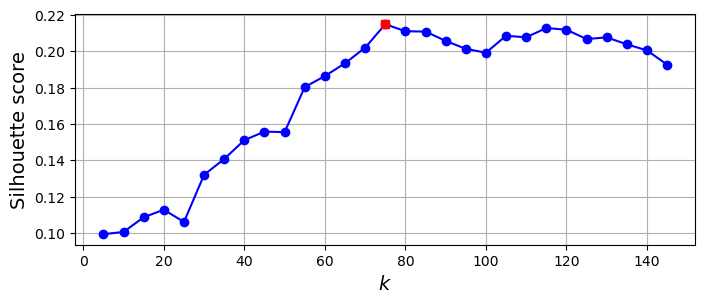

In [69]:
from sklearn.metrics import silhouette_score

silhouette_scores = [silhouette_score(X_train_pca, model.labels_)
                     for model in kmeans_per_k]
best_index = np.argmax(silhouette_scores)
best_k = k_range[best_index]
best_score = silhouette_scores[best_index]

plt.figure(figsize=(8, 3))
plt.plot(k_range, silhouette_scores, "bo-")
plt.xlabel("$k$")
plt.ylabel("Silhouette score")
plt.plot(best_k, best_score, "rs")
plt.grid()
plt.show()

In [70]:
best_k

75

실루엣 점수를 기준으로 선택한 최적의 군집 수는 120으로 상당히 크다. 데이터셋에 40명의 얼굴이 포함되어 있으므로 군집 수도 40개일 것으로 예상할 수 있지만, 같은 사람도 안경 착용 여부나 얼굴의 위치 등에 따라 이미지가 크게 달라질 수 있다.

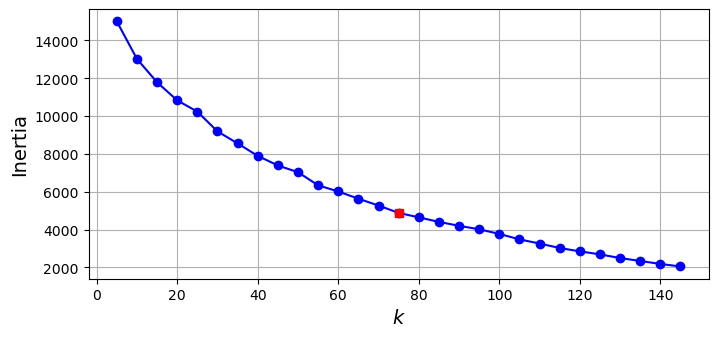

In [71]:
inertias = [model.inertia_ for model in kmeans_per_k]
best_inertia = inertias[best_index]

plt.figure(figsize=(8, 3.5))
plt.plot(k_range, inertias, "bo-")
plt.xlabel("$k$")
plt.ylabel("Inertia")
plt.plot(best_k, best_inertia, "rs")
plt.grid()
plt.show()

관성 그래프에는 뚜렷한 엘보가 나타나지 않아 최적의 군집 수를 판단하기 어렵다. 따라서 실루엣 점수를 기준으로 선택한 120을 사용한다.

In [72]:
best_model = kmeans_per_k[best_index]

각 군집에 포함된 얼굴을 시각화하고 서로 비슷한 얼굴이 모여 있는지 확인한다.

Cluster 0


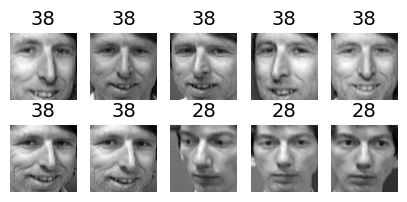

Cluster 1


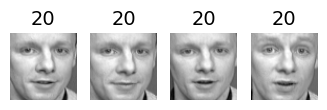

Cluster 2


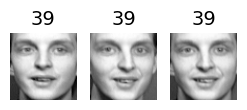

Cluster 3


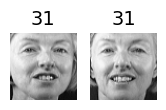

Cluster 4


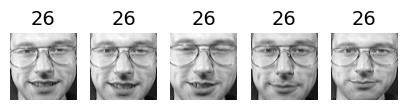

Cluster 5


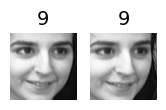

Cluster 6


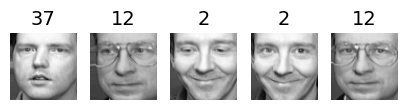

Cluster 7


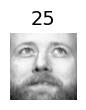

Cluster 8


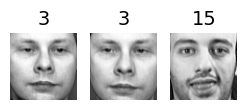

Cluster 9


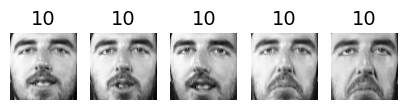

Cluster 10


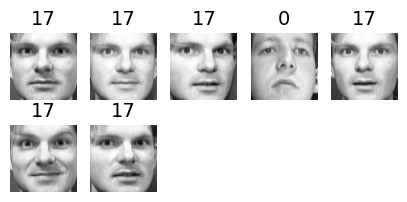

Cluster 11


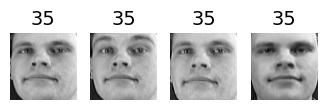

Cluster 12


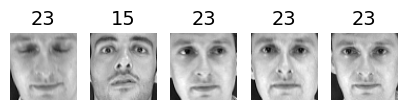

Cluster 13


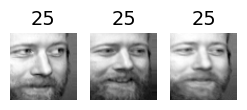

Cluster 14


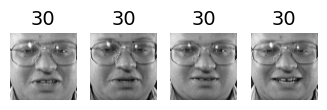

Cluster 15


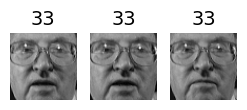

Cluster 16


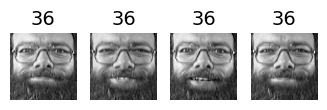

Cluster 17


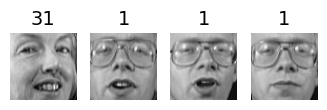

Cluster 18


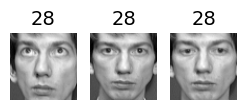

Cluster 19


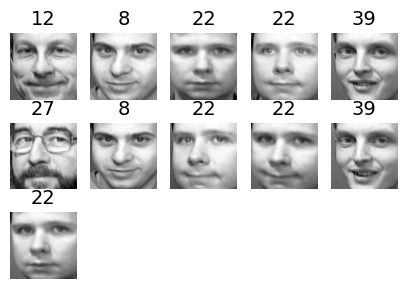

Cluster 20


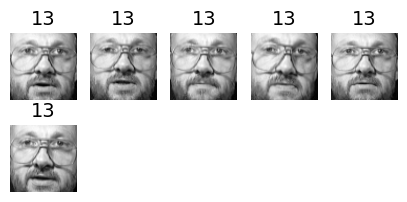

Cluster 21


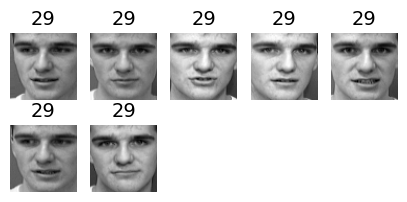

Cluster 22


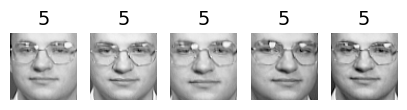

Cluster 23


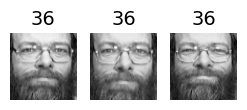

Cluster 24


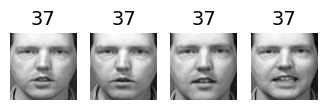

Cluster 25


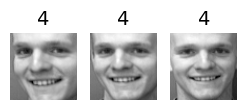

Cluster 26


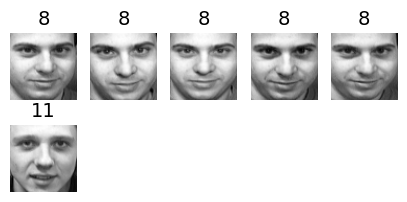

Cluster 27


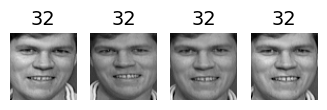

Cluster 28


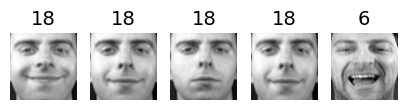

Cluster 29


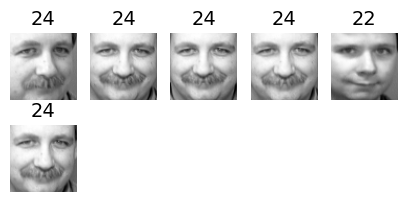

Cluster 30


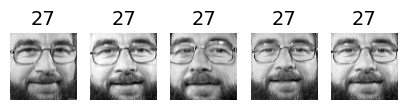

Cluster 31


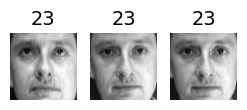

Cluster 32


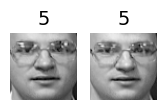

Cluster 33


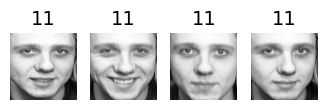

Cluster 34


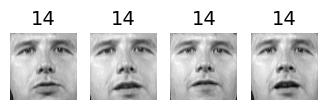

Cluster 35


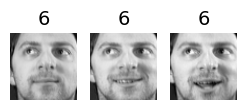

Cluster 36


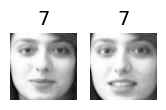

Cluster 37


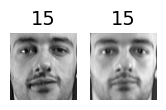

Cluster 38


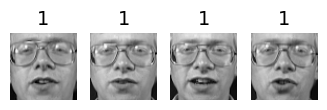

Cluster 39


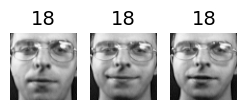

Cluster 40


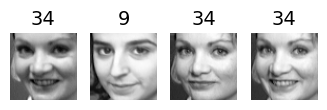

Cluster 41


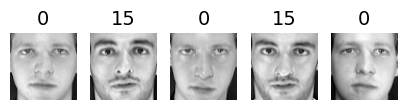

Cluster 42


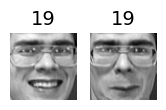

Cluster 43


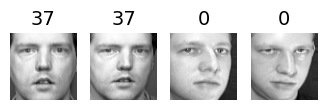

Cluster 44


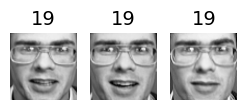

Cluster 45


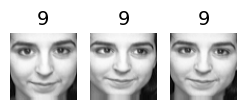

Cluster 46


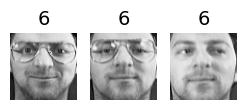

Cluster 47


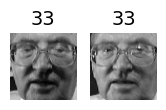

Cluster 48


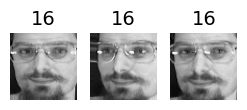

Cluster 49


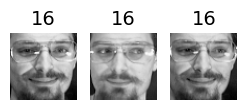

Cluster 50


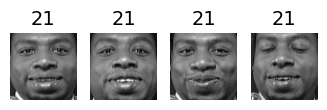

Cluster 51


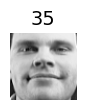

Cluster 52


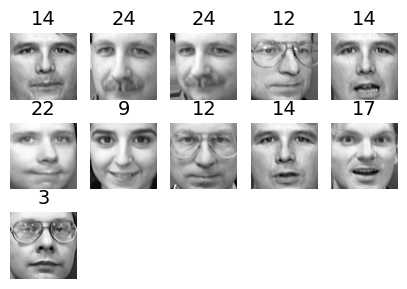

Cluster 53


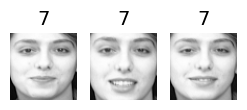

Cluster 54


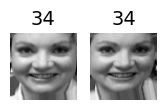

Cluster 55


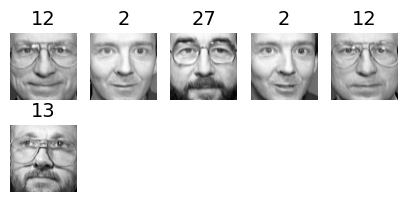

Cluster 56


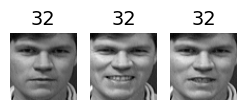

Cluster 57


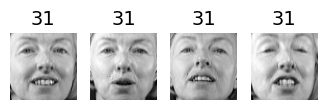

Cluster 58


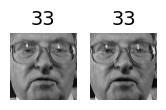

Cluster 59


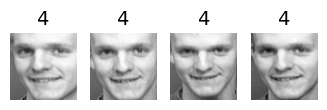

Cluster 60


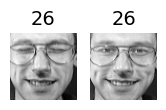

Cluster 61


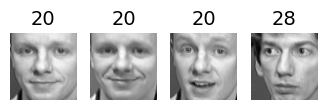

Cluster 62


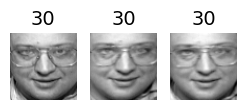

Cluster 63


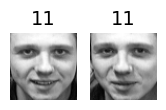

Cluster 64


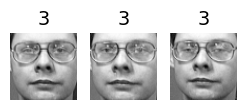

Cluster 65


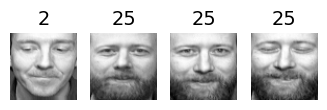

Cluster 66


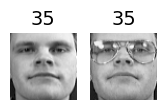

Cluster 67


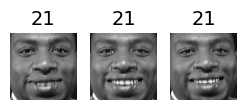

Cluster 68


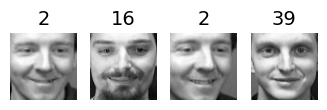

Cluster 69


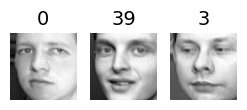

Cluster 70


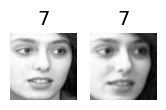

Cluster 71


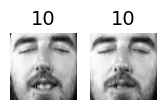

Cluster 72


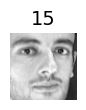

Cluster 73


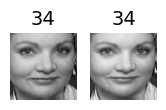

Cluster 74


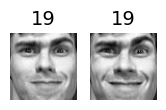

In [73]:
def plot_faces(faces, labels, n_cols=5):
    faces = faces.reshape(-1, 64, 64)
    n_rows = (len(faces) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols, n_rows * 1.1))
    for index, (face, label) in enumerate(zip(faces, labels)):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(face, cmap="gray")
        plt.axis("off")
        plt.title(label)
    plt.show()

for cluster_id in np.unique(best_model.labels_):
    print("Cluster", cluster_id)
    in_cluster = best_model.labels_==cluster_id
    faces = X_train[in_cluster]
    labels = y_train[in_cluster]
    plot_faces(faces, labels)

약 3분의 2에 해당하는 군집에는 동일한 인물의 이미지가 두 개 이상 포함되어 있어 유용하다. 나머지 군집에는 다른 인물의 이미지가 섞여 있거나 이미지가 하나만 포함되어 있다.

이 군집화 결과를 모델 훈련에 직접 활용하기에는 정확도가 충분하지 않을 수 있다. 하지만 새로운 데이터셋에 레이블을 부여할 때 비슷한 이미지를 묶어 주는 용도로 사용하면 작업 시간을 크게 줄일 수 있다.

**문제 2: 분류를 위한 전처리로 군집화 활용**

올리베티 얼굴 이미지에 담긴 인물을 예측하는 분류기를 훈련하고 검증셋에서 성능을 평가한다.

In [74]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=150, random_state=42)
clf.fit(X_train_pca, y_train)
clf.score(X_valid_pca, y_valid)

0.9375

k-평균을 차원 축소 도구로 사용하여 변환된 데이터셋으로 분류기를 훈련한다.

In [75]:
X_train_reduced = best_model.transform(X_train_pca)
X_valid_reduced = best_model.transform(X_valid_pca)
X_test_reduced = best_model.transform(X_test_pca)

clf = RandomForestClassifier(n_estimators=150, random_state=42)
clf.fit(X_train_reduced, y_train)

clf.score(X_valid_reduced, y_valid)

0.7375

분류 성능이 향상되지 않았다. 군집 수를 조정하면 성능이 개선되는지 확인한다.

분류기의 성능을 가장 높이는 군집 수를 찾고 도달할 수 있는 최고 성능을 확인한다.

앞에서처럼 `GridSearchCV`를 사용할 수도 있다. 하지만 검증셋이 이미 준비되어 있고 하나의 하이퍼파라미터만 탐색하므로 반복문을 이용하는 편이 간단하다.

In [76]:
from sklearn.pipeline import make_pipeline

for n_clusters in k_range:
    pipeline = make_pipeline(
        KMeans(n_clusters=n_clusters, random_state=42),
        RandomForestClassifier(n_estimators=150, random_state=42)
    )
    pipeline.fit(X_train_pca, y_train)
    print(n_clusters, pipeline.score(X_valid_pca, y_valid))

5 0.4
10 0.4375
15 0.5875
20 0.6
25 0.6625
30 0.6625
35 0.6625
40 0.675
45 0.6625
50 0.6875
55 0.75
60 0.6875
65 0.725
70 0.7
75 0.7375
80 0.725
85 0.7625
90 0.775
95 0.775
100 0.7625
105 0.75
110 0.725
115 0.7625
120 0.7625
125 0.7375
130 0.7375
135 0.725
140 0.8
145 0.725


군집 수를 조정해도 정확도는 80%를 넘지 못한다. 이 데이터셋에서는 군집 중심까지의 거리가 원본 이미지의 주성분만큼 유용한 정보를 제공하지 못한다.

군집 중심까지의 거리를 원본 특성에 추가하여 분류기를 다시 훈련한다. 이 경우에도 최적의 군집 수를 탐색할 수 있다.

In [77]:
X_train_extended = np.c_[X_train_pca, X_train_reduced]
X_valid_extended = np.c_[X_valid_pca, X_valid_reduced]
X_test_extended = np.c_[X_test_pca, X_test_reduced]

In [78]:
clf = RandomForestClassifier(n_estimators=150, random_state=42)
clf.fit(X_train_extended, y_train)
clf.score(X_valid_extended, y_valid)

0.85

성능이 조금 향상되지만 군집 특성을 사용하지 않은 모델보다 여전히 낮다. 따라서 이 데이터셋에서는 군집 특성이 분류기 훈련에 직접적인 도움이 되지 않는다. 다만 새로운 훈련 샘플에 레이블을 부여하는 작업에는 활용할 수 있다.

**문제 3: 올리베티 얼굴 데이터셋에 가우스 혼합 모델 적용**

올리베티 얼굴 데이터셋으로 가우스 혼합 모델을 훈련한다. 계산 속도를 높이기 위해 전체 분산의 99%를 유지하는 PCA를 적용하여 데이터셋의 차원을 축소한다.

In [79]:
from sklearn.mixture import GaussianMixture

gm = GaussianMixture(n_components=40, random_state=42)
y_pred = gm.fit_predict(X_train_pca)

가우스 혼합 모델의 `sample()` 메서드로 새로운 얼굴을 생성하고 시각화한다. PCA로 차원을 축소했다면 `inverse_transform()` 메서드로 생성된 데이터를 원래 차원으로 복원한다.

In [80]:
n_gen_faces = 20
gen_faces_reduced, y_gen_faces = gm.sample(n_samples=n_gen_faces)
gen_faces = pca.inverse_transform(gen_faces_reduced)

c:\Users\gslee\miniforge3\Lib\site-packages\sklearn\mixture\_base.py:468: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  rng.multivariate_normal(mean, covariance, int(sample))


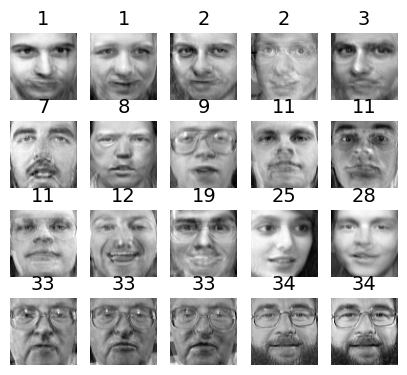

In [81]:
plot_faces(gen_faces, y_gen_faces)

일부 이미지를 회전하거나 뒤집고 어둡게 변형한 다음, 모델이 이를 이상치로 탐지할 수 있는지 확인한다. 정상 이미지와 변형된 이미지에 대한 `score_samples()` 메서드의 결과를 비교한다.

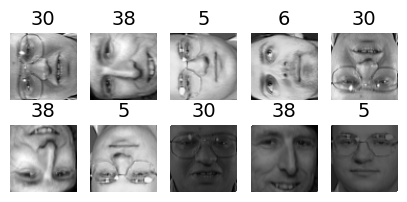

In [82]:
n_rotated = 4
rotated = np.transpose(X_train[:n_rotated].reshape(-1, 64, 64), axes=[0, 2, 1])
rotated = rotated.reshape(-1, 64*64)
y_rotated = y_train[:n_rotated]

n_flipped = 3
flipped = X_train[:n_flipped].reshape(-1, 64, 64)[:, ::-1]
flipped = flipped.reshape(-1, 64*64)
y_flipped = y_train[:n_flipped]

n_darkened = 3
darkened = X_train[:n_darkened].copy()
darkened[:, 1:-1] *= 0.3
y_darkened = y_train[:n_darkened]

X_bad_faces = np.r_[rotated, flipped, darkened]
y_bad = np.concatenate([y_rotated, y_flipped, y_darkened])

plot_faces(X_bad_faces, y_bad)

In [83]:
X_bad_faces_pca = pca.transform(X_bad_faces)

In [84]:
gm.score_samples(X_bad_faces_pca)

array([-1.8582010e+07, -1.7069126e+07, -4.2012412e+07, -4.7338504e+07,
       -3.2009890e+07, -1.3436078e+07, -2.9229658e+07, -8.6622840e+07,
       -9.5834240e+07, -5.0205148e+07], dtype=float32)

가우스 혼합 모델은 변형된 얼굴 이미지에 매우 낮은 로그 확률밀도를 부여한다. 이를 일부 정상 훈련 샘플의 점수와 비교한다.

In [85]:
gm.score_samples(X_train_pca[:10])

array([1162.1312, 1111.2307, 1155.5626, 1170.0619, 1072.6887, 1139.1025,
       1113.0475, 1072.6887, 1047.2766, 1047.2766], dtype=float32)

**문제 4: 차원 축소를 이용한 이상치 탐지**

일부 차원 축소 기법은 이상치 탐지에도 활용할 수 있다. 올리베티 얼굴 데이터셋에 전체 분산의 99%를 유지하는 PCA를 적용한 다음 각 이미지의 재구성 오차를 계산한다. 이어서 앞 문제에서 만든 변형 이미지의 재구성 오차와 비교한다.

변형 이미지의 재구성 오차는 정상 이미지보다 훨씬 크다. 복원된 이미지를 확인하면 PCA가 변형된 이미지도 정상적인 얼굴에 가깝게 재구성하려 한다는 것을 알 수 있다.

앞에서 PCA를 이용하여 데이터셋의 차원을 이미 축소했다.

In [86]:
X_train_pca.round(2)

array([[ -3.78,   1.85,  -5.14, ...,   0.14,  -0.21,   0.06],
       [-10.15,   1.53,  -0.77, ...,  -0.12,  -0.14,  -0.02],
       [ 10.02,  -2.88,  -0.92, ...,  -0.07,  -0.  ,   0.12],
       ...,
       [ -2.48,  -2.96,   1.3 , ...,   0.02,   0.03,  -0.15],
       [  3.22,  -5.35,   1.39, ...,  -0.06,  -0.23,   0.16],
       [  0.92,   3.65,   2.26, ...,  -0.14,  -0.07,   0.06]],
      shape=(280, 199), dtype=float32)

In [87]:
def reconstruction_errors(pca, X):
    X_pca = pca.transform(X)
    X_reconstructed = pca.inverse_transform(X_pca)
    mse = np.square(X_reconstructed - X).mean(axis=-1)
    return mse

In [88]:
reconstruction_errors(pca, X_train).mean()

np.float32(0.0001920535)

In [89]:
reconstruction_errors(pca, X_bad_faces).mean()

np.float32(0.004707354)

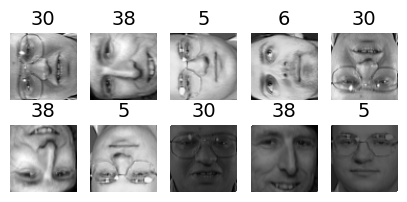

In [90]:
plot_faces(X_bad_faces, y_bad)

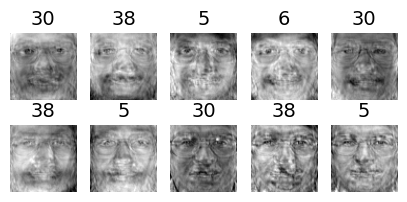

In [91]:
X_bad_faces_reconstructed = pca.inverse_transform(X_bad_faces_pca)
plot_faces(X_bad_faces_reconstructed, y_bad)